# **Demostración de LSTM y GRU (Actividad)**

Las RNN básicas funcionan bien con dependencias a corto plazo, pero sufren del problema del **descenso de gradiente evanescente** cuando se trata de dependencias de contexto a largo plazo. 

Esto se debe a que se pierde información en cada paso de tiempo al recorrer las capas. Las RNN con compuertas tienen unidades diseñadas para olvidar y actualizar la información relevante, lo que puede proporcionar una buena solución a este problema.

En este laboratorio, hablaremos de dos tipos de RNN con compuertas: LSTM y GRU.

## __ Tabla de contenido __

<ol>
    <li><a href="#Objectives">Objectives</a></li>
    <li>
        <a href="#Setup">Setup</a>
        <ol>
            <li><a href="#Installing-Required-Libraries">Installing Required Libraries</a></li>
            <li><a href="#Importing-Required-Libraries">Importing Required Libraries</a></li>
            <li><a href="#Defining-Helper-Functions">Defining Helper Functions</a></li>
        </ol>
    </li>
    <li>
        <a href="#Gated-RNNs">Gated RNNs</a>
        <ol>
            <li><a href="#LSTM">LSTM</a></li>
            <li><a href="#GRU">GRU</a></li>
            <li><a href="#LSTM in Keras: Time-series forecasting">LSTM in Keras: Time-series forecasting</a></li>
            <li><a href="#Exercise 1: GRU in Keras - Reuters classification">Exercise 1: GRU in Keras - Reuters classification</a></li>
        </ol>
    </li>


## Objetivos

Al finalizar este laboratorio, podrás:

- Explicar los componentes fundamentales de LSTM y GRU

- Implementar LSTM y GRU en Keras para diversas tareas y aplicaciones

## Configuración

Para este laboratorio, utilizaremos las siguientes bibliotecas:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### Instalación de las bibliotecas necesarias

Las siguientes bibliotecas necesarias vienen preinstaladas en el entorno de Skills Network Labs. Sin embargo, si ejecuta estos comandos del notebook en un entorno Jupyter diferente (como Watson Studio o Anaconda), deberá instalarlas eliminando el símbolo `#` que precede a `!mamba` en la siguiente celda de código.

In [8]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1
# Note: If your environment doesn't support "!mamba install", use "!pip install"

Las siguientes bibliotecas necesarias no están preinstaladas en el entorno de Skills Network Labs. Deberá ejecutar la siguiente celda para instalarlas:

In [10]:
%%capture

!mamba install -qy tqdm
!pip install tensorflow --upgrade

### Importación de las bibliotecas necesarias

In [12]:
# --- Configuración para silenciar advertencias (warnings) ---
import warnings
import os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

# --- Librerías base ---
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuración y verificación de TensorFlow ---
import tensorflow as tf
print(f"TensorFlow versión: {tf.__version__}")

# --- Herramientas de Deep Learning (Estructura Unificada) ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, SimpleRNN, LSTM, GRU, Embedding, 
    Masking, Conv1D, Dropout, Layer
)
from tensorflow.keras.optimizers import Adam

# SOLUCIÓN AL IMPORT ERROR: 
# En TF 2.21, importamos la clase con Mayúsculas. 
# La función en minúsculas se maneja mejor internamente o vía tf.keras.metrics.
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanSquaredError as MSE_Metric

# --- Preprocesamiento de Texto y Secuencias ---
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator, pad_sequences
from tensorflow.keras.datasets import reuters

# --- Preprocesamiento y Utilidades de Scikit-Learn ---
from sklearn.preprocessing import MinMaxScaler

# --- Configuración estética y reproducibilidad ---
sns.set_theme(style='white', context='notebook')
np.random.seed(2026)
tf.random.set_seed(2026)

TensorFlow versión: 2.21.0


## Gated RNN


Los dos tipos de RNN con compuertas que estudiaremos en este laboratorio son las Memorias a Largo y Corto Plazo (LSTM) y las Unidades Recurrentes con Compuertas (GRU). Las GRU son más simples que las LSTM. Son mucho más rápidas y se optimizan con mayor rapidez.

### LSTM

La idea clave de las LSTM es tener dos representaciones de estado: el estado oculto $\mathbf h$ y el estado de la celda $\mathbf C$ (en lugar de $\mathbf s$).

Una celda LSTM tiene una estructura interna compleja que le permite:

* Aprender a reconocer una entrada importante,
* Almacenarla en el estado a largo plazo,
* Conservarla durante el tiempo que sea necesario,
* Extraerla cuando sea necesario.

<img src="https://wiki.math.uwaterloo.ca/statwiki/images/thumb/9/98/LSTM.png/800px-LSTM.png" alt="Source: http://colah.github.io/posts/2015-08-Understanding-LSTMs/" style="width: 500px;"> 

Source: http://colah.github.io/posts/2015-08-Understanding-LSTMs/

Las redes LSTM tienen la capacidad de añadir o eliminar información del estado de la celda, reguladas cuidadosamente por estructuras llamadas compuertas, que permiten el paso opcional de información. Una red LSTM cuenta con tres compuertas: compuerta de olvido, compuerta de entrada y compuerta de salida. Estas se componen de una capa de red neuronal sigmoide. Las capas basadas en la función sigmoide generan valores cercanos a 0 (compuerta cerrada) o 1 (compuerta abierta).

### GRU

GRU es una simplificación de la celda LSTM que ofrece un rendimiento similar, pero con un entrenamiento más rápido. Cuenta con un único controlador de puerta de actualización que gestiona las puertas de olvido y de entrada. Cuando una está abierta, la otra se cierra. No tiene puerta de salida. La puerta de reinicio controla qué parte del estado anterior se muestra a la capa principal. El modelo resultante es más simple que los modelos LSTM estándar. Las GRU tienen menos parámetros y, por lo tanto, pueden entrenarse un poco más rápido o requerir menos datos para generalizar.


<img src="https://github.com/DataScienceUB/DeepLearningMaster2019/blob/master/images/gru.png?raw=1" alt="Source: http://colah.github.io/posts/2015-08-Understanding-LSTMs/" style="width: 300px;"> 


### LSTM en Keras: Pronóstico de series temporales


A continuación, construiremos un modelo LSTM simple para resolver un problema de predicción de series temporales de muchos a uno en una onda sinusoidal simulada.

Comencemos generando algunas ondas sinusoidales utilizando la función `np.sin()`.

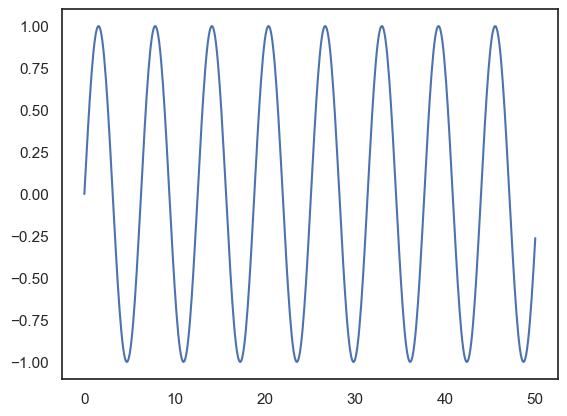

In [20]:
# Crea un arreglo de 501 puntos distribuidos linealmente entre 0 y 50
# Esto define el eje X (el dominio de la función)
x = np.linspace(0, 50, 501)

# Calcula el seno de cada uno de los valores del arreglo 'x'
# Esto define el eje Y (el rango de la función)
y = np.sin(x)

# Genera el gráfico de línea conectando los puntos (x, y)
plt.plot(x, y)

# (Opcional) Muestra la gráfica en pantalla
plt.show()

La convertiremos en un marco de datos para mayor comodidad.

In [22]:
# Crea un objeto DataFrame utilizando:
# - data: Los valores de la función seno (eje Y)
# - index: Los valores de tiempo/espacio (eje X) como etiquetas de las filas
# - columns: El nombre que recibirá la columna de datos
df = pd.DataFrame(data=y, index=x, columns=['Sine'])
df

,Sine
0.0,0.000000
0.1,0.099833
0.2,0.198669
0.3,0.295520
0.4,0.389418
...,...
49.6,-0.617439
49.7,-0.535823
49.8,-0.448854
49.9,-0.357400


Estamos trabajando con una serie temporal univariada, por lo que tenemos un total de una característica. Usaremos el 10% de los datos simulados para las pruebas.

In [24]:
# Porcentaje de los datos totales que se reservará para el conjunto de prueba (10%)
test_percent = 0.1

# Número de características (variables) de entrada; en series temporales univariadas es 1
n_features = 1

# Longitud de la secuencia: el modelo mirará 50 pasos atrás para predecir el siguiente
length = 50

# Tamaño del lote: cantidad de muestras que procesa la red antes de actualizar los pesos
batch_size = 1

Ahora vamos a crear un conjunto de datos de entrenamiento y prueba para entrenar y probar nuestro modelo.

In [26]:
# Calcula el número de puntos destinados a la prueba redondeando el % del total
# Si tienes 501 puntos y el 10% es test, esto dará 50 puntos
test_point = np.round(len(df) * test_percent)

# Encuentra el índice exacto donde debe cortarse el DataFrame
# Resta los puntos de prueba al total para obtener el punto de división
test_ind = int(len(df) - test_point)

# Crea el conjunto de entrenamiento: desde el inicio hasta el índice de corte
train = df.iloc[:test_ind]

# Crea el conjunto de prueba: desde el índice de corte hasta el final de los datos
test = df.iloc[test_ind:]

Realizaremos un preprocesamiento básico utilizando el `MinMaxScaler`, que normaliza la entrada.

In [36]:
# Inicializa el escalador para normalizar los datos
scaler = MinMaxScaler()

# Ajusta el escalador con los datos de entrenamiento y los transforma.
# 'fit' calcula el mínimo y máximo; 'transform' aplica la fórmula (x - min) / (max - min)
scaled_train = scaler.fit_transform(train)

# Transforma los datos de prueba usando los mismos parámetros del entrenamiento.
# IMPORTANTE: Aquí NO se usa fit para evitar "filtración de datos" (data leakage)
scaled_test = scaler.transform(test)

`TimeseriesGenerator` es una clase de utilidad de Keras que se utiliza para generar lotes de datos temporales. Con nuestros datos de entrenamiento escalados, creamos 401 secuencias de salida.

In [38]:
print(f"""
Tamaño scaled_train: {len(scaled_train)}
Tamaño length: {length}
Batch size: {batch_size}
""")


Tamaño scaled_train: 451
Tamaño length: 50
Batch size: 1



In [40]:
# Crea un generador que organiza los datos para el entrenamiento de la red neuronal
# - Los primeros dos argumentos (scaled_train, scaled_train) indican que usará los datos para predecir los mismos datos (aprendizaje supervisado)
# - length: define cuántos pasos previos (ventanas) usará el modelo para predecir el siguiente valor
# - batch_size: determina cuántas muestras de estas ventanas se procesarán por cada actualización del modelo
generator = TimeseriesGenerator(scaled_train, scaled_train, length=length, batch_size=batch_size)

# Devuelve la cantidad total de lotes (batches) que el generador puede producir
# Es igual a: (Total de muestras - longitud de ventana) / tamaño del lote
len(generator)

401

Utilizaremos la capa `LSTM()` con 50 unidades y una forma de entrada definida por la longitud de la secuencia y el número de características.

In [42]:
# Inicializa un modelo secuencial (una pila de capas donde cada una tiene un solo tensor de entrada y salida)
model = Sequential()

# Añade una capa LSTM (Long Short-Term Memory)
# - 50: Es el número de neuronas (unidades) en la capa
# - input_shape: Define la estructura de los datos de entrada (50 pasos atrás, 1 característica)
model.add(LSTM(50, input_shape=(length, n_features)))

# Añade una capa densa (completamente conectada) al final
# - 1: El modelo produce un solo valor de salida (la predicción del siguiente punto en la serie)
model.add(Dense(1))

# Configura el proceso de aprendizaje
# - optimizer='adam': Algoritmo de optimización que ajusta los pesos de forma eficiente
# - loss='mse': Función de pérdida de Error Cuadrático Medio, ideal para problemas de regresión
model.compile(optimizer='adam', loss='mse')

In [44]:
# Inicia el entrenamiento del modelo utilizando el generador de datos
# - generator: El objeto que creamos antes para entregar los datos en lotes (batches)
# - epochs=6: El número de veces que el modelo recorrerá el conjunto de datos completo
model.fit(generator, epochs=6)

Epoch 1/6
401/401 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0168
Epoch 2/6
401/401 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 7.6604e-05
Epoch 3/6
401/401 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 2.4719e-04
Epoch 4/6
401/401 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 2.9750e-04
Epoch 5/6
401/401 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 9.1091e-05
Epoch 6/6
401/401 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 1.0915e-04


Ahora evaluaremos el rendimiento de la red LSTM al pronosticar algunos pasos de tiempo a partir del primer lote.

In [45]:
# Lista vacía para ir guardando cada una de las predicciones futuras
forecast = []

# Tomamos los últimos '50' puntos del entrenamiento para empezar a predecir
# Este es el "trampolín" desde el cual el modelo saltará al futuro
first_eval_batch = scaled_train[-length:]

# Redimensionamos los datos para que coincidan con lo que espera la red: (1, 50, 1)
# (Batch_size, Length, Features)
current_batch = first_eval_batch.reshape((1, length, n_features))

# Bucle para predecir los siguientes 25 puntos de forma recursiva
for i in range(25):
    
    # El modelo predice el siguiente punto basado en el lote actual
    # [0] se usa para obtener el valor escalar dentro del array de salida
    current_pred = model.predict(current_batch, verbose=0)[0]
    
    # Guardamos la predicción en nuestra lista
    forecast.append(current_pred)
    
    # ACTUALIZACIÓN DEL LOTE (Lógica de ventana deslizante):
    # 1. Eliminamos el primer elemento del lote actual: current_batch[:, 1:, :]
    # 2. Añadimos la predicción recién hecha al final: [[current_pred]]
    # Esto permite que la siguiente predicción se base en la predicción anterior
    current_batch = np.append(current_batch[:, 1:, :], [[current_pred]], axis=1)

Invertiremos la escala min-max de las predicciones para permitir una comparación directa con los datos reales.

In [50]:
# Convierte las predicciones normalizadas (0 a 1) de vuelta a sus valores reales
# Se utiliza el escalador que "aprendió" el mínimo y el máximo de los datos originales
forecast = scaler.inverse_transform(forecast)

In [52]:
# Crea un arreglo de números para el eje X que representa el "futuro"
# - 50.1: Punto de inicio (justo después del último valor de tu entrenamiento/prueba)
# - 52.6: Punto final (calculado para cubrir los 25 pasos de predicción: 25 * 0.1 = 2.5)
# - step=0.1: El mismo intervalo que usamos en el linspace original
forecast_index = np.arange(50.1, 52.6, step=0.1)

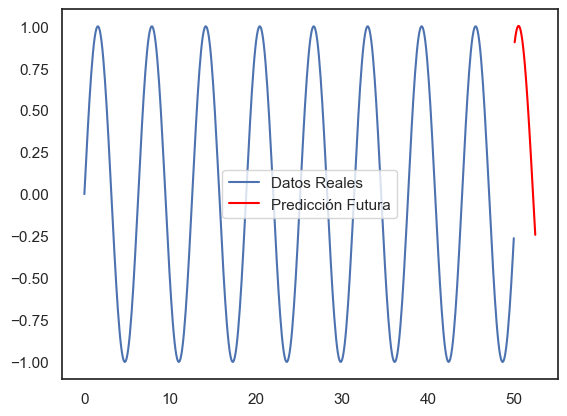

In [54]:
# Grafica los datos originales completos (la onda senoidal base)
# df.index son los valores de 0 a 50; df['Sine'] son los valores reales
plt.plot(df.index, df['Sine'], label='Datos Reales')

# Grafica las predicciones calculadas por el modelo LSTM
# forecast_index son los nuevos puntos (50.1 a 52.5) y forecast son los valores predichos
plt.plot(forecast_index, forecast, label='Predicción Futura', color='red')

# Añade una leyenda para identificar qué línea es cuál
plt.legend()

# (Opcional) Muestra el gráfico final
plt.show()

### Ejercicio 1: GRU en Keras - Clasificación de Reuters

En este ejercicio, utilizarás el conjunto de datos de Reuters de Keras que importamos anteriormente para construir un modelo de clasificación utilizando GRU.

El conjunto de datos utilizado es el de noticias de **Reuters** de Keras. Contiene $11,228$ noticias de Reuters, etiquetadas en $46$ temas.

> Cada noticia se codifica como una lista de índices de palabras (enteros). Para mayor comodidad, las palabras se indexan según su frecuencia general en el conjunto de datos; por ejemplo, el entero "3" codifica la tercera palabra más frecuente. Esto permite realizar filtrados rápidos, como por ejemplo: "considerar solo las 10.000 palabras más comunes y eliminar las 20 más comunes".

Devuelve lo siguiente:

> x_train, x_test: listas de secuencias, que a su vez son listas de índices (enteros). Si el argumento `num_words` es específico, el valor máximo posible del índice es `num_words - 1`.

Comencemos definiendo algunos hiperparámetros.

* Usamos 10 000 para especificar `num_words`, es decir, el valor máximo de índice posible cargado es `num_words` - 1.

* La longitud de entrada de la capa de incrustación se especifica mediante `maxlen`.

* Usaremos el 30 % de los datos para las pruebas.

In [56]:
# Define el tamaño del vocabulario: solo se conservarán las 10,000 palabras más frecuentes
# Las palabras menos comunes se descartarán para reducir el ruido y la memoria
num_words = 10000

# Longitud máxima de cada noticia: si un texto tiene más de 1000 palabras, se recorta;
# si tiene menos, se rellena con ceros (padding) para que todas midan lo mismo
maxlen = 1000

# Define la proporción para el conjunto de prueba (30% de los datos totales)
# El 70% restante se utilizará para entrenar el modelo
test_split = 0.3

A continuación, utilizaremos la API de Keras para cargar nuestro conjunto de datos de Reuters.

In [58]:
# Carga el dataset Reuters filtrando por el número de palabras más frecuentes
# - num_words: Limita el vocabulario a las top 10,000 palabras definidas antes
# - test_split: Reserva el 30% de los datos para validación
# X contiene las noticias (secuencias de números) y y contiene las etiquetas (temas)
(X_train, y_train), (X_test, y_test) = reuters.load_data(num_words=num_words, test_split=test_split)

# Imprime la cantidad de noticias disponibles para el entrenamiento
print(len(X_train), 'train sequences')

# Imprime la cantidad de noticias disponibles para la evaluación final
print(len(X_test), 'test sequences')

7859 train sequences
3369 test sequences


En cuanto al preprocesamiento, rellenamos las secuencias hasta alcanzar la misma longitud utilizando `pad_sequences`. Las secuencias más largas que `num_timesteps` se truncan para que se ajusten a la longitud deseada. Por otro lado, las secuencias más cortas que `num_timesteps` se rellenan hasta alcanzar una longitud igual a `num_timesteps`.

In [60]:
# --- Preprocesamiento de datos ---

# Estandariza la longitud de las secuencias de texto
# - Si la noticia es más larga que 'maxlen' (1000), se recorta.
# - Si es más corta, se rellena con ceros al principio (padding).
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

# Muestra las nuevas dimensiones: (Número de muestras, 1000 palabras por muestra)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (7859, 1000)
X_test shape: (3369, 1000)


In [62]:
y_train[[1]]

array([4], dtype=int64)

In [64]:
# Convierte las etiquetas enteras (0-45) en vectores binarios (One-Hot Encoding)
# Ejemplo: la categoría 3 se convierte en [0, 0, 0, 1, 0, ..., 0]
# Esto es necesario porque el modelo tiene 46 neuronas de salida (una por cada tema).
y_train = tf.keras.utils.to_categorical(y_train, 46)
y_test = tf.keras.utils.to_categorical(y_test, 46)

In [66]:
y_train[[1]]

array([[0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

Comience definiendo la arquitectura del modelo. Utilice una capa `GRU` con 128 unidades y una tasa de abandono (dropout) de 0,2. Utilice una capa densa con 46 unidades y softmax como función de activación. Imprima el resumen del modelo.

In [69]:
# Inicializa el modelo secuencial
model = Sequential()

# Capa Embedding: Convierte palabras (índices) en vectores densos de significado
# - input_dim (10,000): Tamaño del vocabulario
# - output_dim (300): Cada palabra será representada por un vector de 300 dimensiones
# - input_length (1000): Longitud de las noticias de entrada
model.add(Embedding(input_dim=num_words, output_dim=300, input_length=maxlen))

# Capa GRU (Gated Recurrent Unit): Una variante de RNN más eficiente que la LSTM
# - 128: Número de unidades (neuronas) en la capa
# - dropout=0.2: Técnica de regularización para evitar el sobreajuste (apaga el 20% de las neuronas al azar)
model.add(GRU(128, dropout=0.2))

# Capa de salida densa
# - 46: Una neurona por cada categoría de noticias en el dataset Reuters
# - activation='softmax': Convierte la salida en probabilidades (la suma de todas será 1.0)
model.add(Dense(46, activation='softmax'))

# Muestra el resumen de la arquitectura, incluyendo el número de parámetros a entrenar
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Ahora, compile el modelo utilizando la función de pérdida `categorical_crossentropy`, el optimizador `adam` y la precisión como métrica. Entrene el modelo con un tamaño de lote de 256, durante 10 iteraciones de entrenamiento y utilizando el 20 % de los datos para la validación. Finalmente, evalúe el rendimiento del modelo en el conjunto de datos de prueba.

In [72]:
# --- Configuración del aprendizaje ---
# loss='categorical_crossentropy': Función de pérdida obligatoria para clasificación multiclase (46 categorías)
# optimizer='adam': Algoritmo que ajusta los pesos de la red de forma eficiente y rápida
# metrics=['accuracy']: Monitorizamos la precisión (porcentaje de aciertos) durante el proceso
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# --- Proceso de entrenamiento ---
# X_train, y_train: Datos de entrada y sus etiquetas correspondientes
# batch_size=256: Procesa 256 noticias antes de actualizar los pesos de la red (equilibrio entre velocidad y estabilidad)
# epochs=10: El modelo pasará 10 veces completas por todo el set de datos
# validation_split=0.2: Reserva el 20% del entrenamiento para evaluar el modelo al final de cada época (evita el sobreajuste)
model.fit(X_train, y_train, batch_size=256, epochs=10, validation_split=0.2)

# --- Evaluación final ---
# Comprueba el rendimiento real del modelo usando el conjunto de prueba que separamos al principio
# Devuelve la pérdida final y la precisión (accuracy) alcanzada
model.evaluate(X_test, y_test)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 237s 9s/step - accuracy: 0.3460 - loss: 2.8830 - val_accuracy: 0.3696 - val_loss: 2.3027
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 342s 14s/step - accuracy: 0.4240 - loss: 2.1428 - val_accuracy: 0.4777 - val_loss: 2.0043
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 469s 17s/step - accuracy: 0.4945 - loss: 1.9044 - val_accuracy: 0.5305 - val_loss: 1.7985
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 522s 21s/step - accuracy: 0.5554 - loss: 1.6985 - val_accuracy: 0.5585 - val_loss: 1.6894
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 660s 27s/step - accuracy: 0.5782 - loss: 1.6006 - val_accuracy: 0.5732 - val_loss: 1.6703
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 692s 28s/step - accuracy: 0.6162 - loss: 1.4956 - val_accuracy: 0.5922 - val_loss: 1.6437
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 684s 26s/step - accuracy: 0.6426 - loss: 1.4175 - val_accuracy: 0.5941 - val_loss: 1.6528
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 710s 29s/step - accuracy: 0.6548 - loss: 1.3589 - val_accuracy: 0.5

[1.6476666927337646, 0.6064113974571228]